# 01 - EDA: ASVspoof 2019/2021 LA

Разведочный анализ данных для детекции голосовых дипфейков.
- **train / dev**: ASVspoof 2019 LA
- **eval**: ASVspoof 2021 LA

## Импорты

In [20]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torchaudio
import soundfile as sf
from tqdm.notebook import tqdm
from scipy.signal import spectrogram as scipy_spectrogram

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (8, 4)

## ASVspoof 2019 LA

In [21]:
DATASET_ROOT = "/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset"

LA_ROOT = f"{DATASET_ROOT}/LA/LA"
PROTO_DIR = f"{LA_ROOT}/ASVspoof2019_LA_cm_protocols"
TRAIN_FLAC = f"{LA_ROOT}/ASVspoof2019_LA_train/flac"
DEV_FLAC = f"{LA_ROOT}/ASVspoof2019_LA_dev/flac"

PROTO_TRAIN = f"{PROTO_DIR}/ASVspoof2019.LA.cm.train.trn.txt"
PROTO_DEV = f"{PROTO_DIR}/ASVspoof2019.LA.cm.dev.trl.txt"
PROTO_EVAL = f"{PROTO_DIR}/ASVspoof2019.LA.cm.eval.trl.txt"

In [22]:
def parse_protocol(path: str) -> pd.DataFrame:
    rows = []
    with open(path) as f:
        for line in f:
            p = line.split()
            rows.append({
                "speaker": p[0],
                "file_id": p[1],
                "attack": p[3],
                "label": p[4],
            })
    return pd.DataFrame(rows)

train_df = parse_protocol(PROTO_TRAIN)
dev_df = parse_protocol(PROTO_DEV)

print(f"Train: {len(train_df):>6} записей")
print(f"Dev: {len(dev_df):>6} записей")
train_df.head()

Train:  25380 записей
Dev:  24844 записей


,speaker,file_id,attack,label
0,LA_0079,LA_T_1138215,-,bonafide
1,LA_0079,LA_T_1271820,-,bonafide
2,LA_0079,LA_T_1272637,-,bonafide
3,LA_0079,LA_T_1276960,-,bonafide
4,LA_0079,LA_T_1341447,-,bonafide


## Графики

### Баланс классов

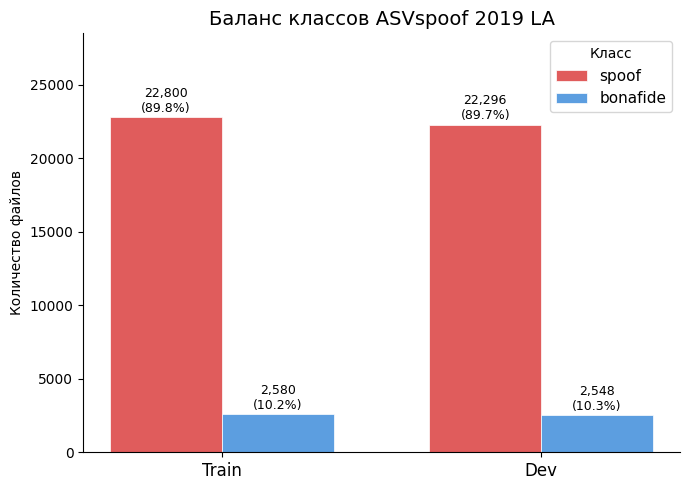

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))

labels = ["Train", "Dev"]
classes = ["spoof", "bonafide"]
colors = {"spoof": "#e05c5c", "bonafide": "#5c9ee0"}
bar_w = 0.35
x = range(len(labels))

for i, cls in enumerate(classes):
    counts = [df[df.label == cls].shape[0]
              for df in [train_df, dev_df]]
    offset = (i - 0.5) * bar_w
    bars = ax.bar([xi + offset for xi in x], counts,
                    width=bar_w, color=colors[cls], label=cls,
                    edgecolor="white", linewidth=0.5)

    for bar, val, df in zip(bars, counts, [train_df, dev_df]):
        pct = val / len(df) * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 150,
                f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Количество файлов")
ax.set_ylim(0, train_df.label.value_counts().max() * 1.25)
ax.set_title("Баланс классов ASVspoof 2019 LA", fontsize=14)
ax.legend(title="Класс", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [24]:
for df, name in [(train_df, "Train"), (dev_df, "Dev")]:
    n_bon = (df.label == "bonafide").sum()
    n_spo = (df.label == "spoof").sum()
    ratio = n_spo / n_bon
    print(f"{name:6}  bonafide = {n_bon:>5}  spoof = {n_spo:>6}  "
          f"spoof/bonafide = {ratio:.1f}  "
          f"вес bonafide в CE: {ratio:.1f}")

Train   bonafide =  2580  spoof =  22800  spoof/bonafide = 8.8  вес bonafide в CE: 8.8
Dev     bonafide =  2548  spoof =  22296  spoof/bonafide = 8.8  вес bonafide в CE: 8.8


In [25]:
def get_durations(df, flac_dir):
    durations = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        path = f"{flac_dir}/{row.file_id}.flac"
        info = sf.info(path)
        durations.append(info.duration)   # num_frames / sample_rate
    return durations

train_df["duration"] = get_durations(train_df, TRAIN_FLAC)
dev_df["duration"] = get_durations(dev_df, DEV_FLAC)

  0%|          | 0/25380 [00:00<?, ?it/s]

  0%|          | 0/24844 [00:00<?, ?it/s]

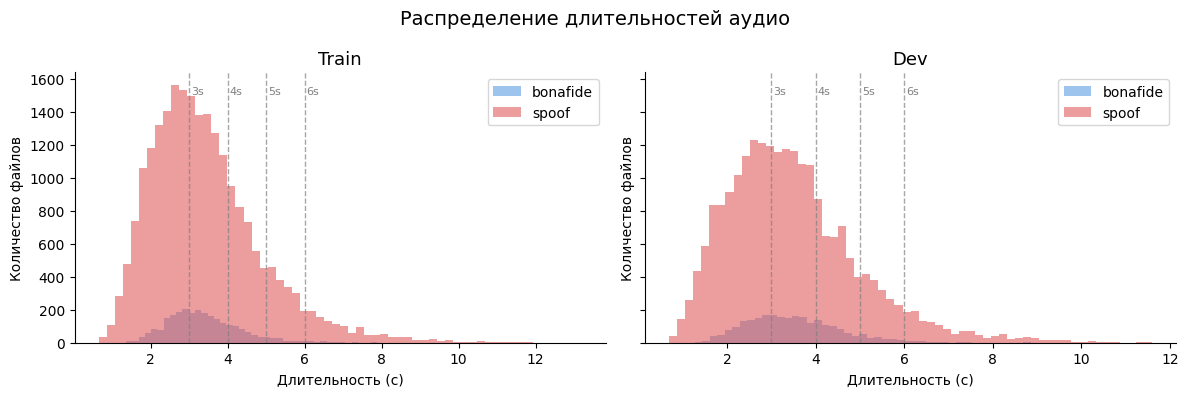

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

thresholds = [3, 4, 5, 6]
colors = {"bonafide": "#5c9ee0", "spoof": "#e05c5c"}

for ax, (df, name) in zip(axes, [(train_df, "Train"), (dev_df, "Dev")]):
    for label in ["bonafide", "spoof"]:
        subset = df[df.label == label]["duration"]
        ax.hist(subset, bins=60, alpha=0.6,
                color=colors[label], label=label, edgecolor="none")

    for t in thresholds:
        ax.axvline(t, linestyle="--", linewidth=1, color="gray", alpha=0.7)
        ax.text(t + 0.05, ax.get_ylim()[1] * 0.95, f"{t}s",
                fontsize=8, color="gray", va="top")

    ax.set_title(f"{name}", fontsize=13)
    ax.set_xlabel("Длительность (с)")
    ax.set_ylabel("Количество файлов")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Распределение длительностей аудио", fontsize=14)
plt.tight_layout()
plt.show()

In [28]:
print(f"{'':12} {'min':>6} {'median':>8} {'max':>6} {'mean':>7}")
print("-" * 45)
for df, name in [(train_df, "Train"), (dev_df, "Dev")]:
    for label in ["bonafide", "spoof"]:
        d = df[df.label == label]["duration"]
        print(f"{name+'/'+label:12} "
              f"{d.min():>6.2f} {d.median():>8.2f} "
              f"{d.max():>6.2f} {d.mean():>7.2f}")

print("\nПроцент файлов короче порога:")
print(f"{'порог':>8}", end="")
for label in ["bonafide", "spoof"]:
    print(f"  {label:>10}", end="")
print()
for t in thresholds:
    print(f"{t:>6}s  ", end="")
    for label in ["bonafide", "spoof"]:
        d = train_df[train_df.label == label]["duration"]
        pct = (d < t).mean() * 100
        print(f"  {pct:>9.1f}%", end="")
    print()

                min   median    max    mean
---------------------------------------------
Train/bonafide   1.36     3.24  11.13    3.39
Train/spoof    0.65     3.20  13.19    3.43
Dev/bonafide   1.28     3.39  11.39    3.51
Dev/spoof      0.70     3.27  11.59    3.47

Процент файлов короче порога:
   порог    bonafide       spoof
     3s         38.2%       44.4%
     4s         76.5%       72.0%
     5s         93.9%       87.0%
     6s         98.1%       94.3%


In [9]:
MAX_SECONDS  = 6.0
SAMPLE_RATE  = 16_000
MAX_SAMPLES = int(MAX_SECONDS * SAMPLE_RATE)   # 64 000 сэмплов

print(f"max_seconds : {MAX_SECONDS}")
print(f"max_samples : {MAX_SAMPLES:,}  ({MAX_SECONDS}с × {SAMPLE_RATE}Hz)")

max_seconds : 6.0
max_samples : 96,000  (6.0с × 16000Hz)


In [10]:
def load_sample(df, label, flac_dir):
    row = df[df.label == label].sample(1, random_state=42).iloc[0]
    wav, sr = torchaudio.load(f"{flac_dir}/{row.file_id}.flac")
    return wav.squeeze(0).numpy(), sr, row

bon_wav, bon_sr, bon_row = load_sample(train_df, "bonafide", TRAIN_FLAC)
spo_wav, spo_sr, spo_row = load_sample(train_df, "spoof",    TRAIN_FLAC)

print(f"bonafide: {bon_row.file_id}  {len(bon_wav)/bon_sr:.2f}с  атака: {bon_row.attack}")
print(f"spoof:    {spo_row.file_id}  {len(spo_wav)/spo_sr:.2f}с  атака: {spo_row.attack}")

bonafide: LA_T_3891170  3.97с  атака: -
spoof:    LA_T_7196016  2.09с  атака: A01


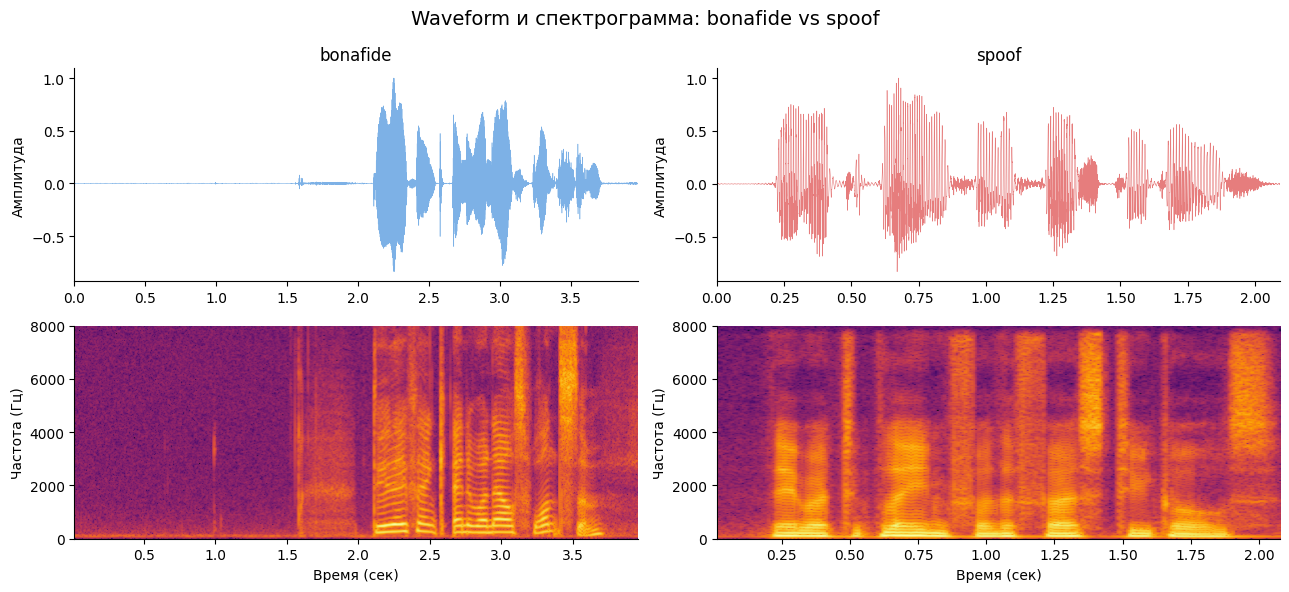

In [11]:
def plot_sample(ax_wave, ax_spec, wav, sr, title, color):
    t = np.linspace(0, len(wav) / sr, len(wav))

    # waveform
    ax_wave.plot(t, wav, color=color, linewidth=0.4, alpha=0.8)
    ax_wave.set_title(title, fontsize=12)
    ax_wave.set_ylabel("Амплитуда")
    ax_wave.set_xlim(0, t[-1])
    ax_wave.spines[["top", "right"]].set_visible(False)

    # спектрограмма (лог-мел)
    ax_spec.specgram(wav, NFFT=512, Fs=sr, noverlap=400,
                     cmap="inferno", scale="dB")
    ax_spec.set_ylabel("Частота (Гц)")
    ax_spec.set_xlabel("Время (сек)")
    ax_spec.spines[["top", "right"]].set_visible(False)

fig, axes = plt.subplots(2, 2, figsize=(13, 6))

plot_sample(axes[0][0], axes[1][0],
            bon_wav, bon_sr,
            "bonafide", "#5c9ee0")

plot_sample(axes[0][1], axes[1][1],
            spo_wav, spo_sr,
            "spoof", "#e05c5c")

plt.suptitle("Waveform и спектрограмма: bonafide vs spoof", fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
def load_sample(df, label, flac_dir, attack=None, random_state=42):
    subset = df[df.label == label]
    if attack:
        subset = subset[subset.attack == attack]
    row = subset.sample(1, random_state=random_state).iloc[0]
    wav, sr = torchaudio.load(f"{flac_dir}/{row.file_id}.flac")
    return wav.squeeze(0).numpy(), sr, row

bon_wav,  bon_sr,  bon_row  = load_sample(train_df, "bonafide", TRAIN_FLAC)
spo_a01_wav, spo_sr, spo_a01_row = load_sample(train_df, "spoof", TRAIN_FLAC, attack="A01")
spo_a03_wav, _, spo_a03_row = load_sample(train_df, "spoof", TRAIN_FLAC, attack="A03")
spo_a06_wav, _, spo_a06_row = load_sample(train_df, "spoof", TRAIN_FLAC, attack="A06")

for wav, row in [(bon_wav, bon_row), (spo_a01_wav, spo_a01_row),
                 (spo_a03_wav, spo_a03_row), (spo_a06_wav, spo_a06_row)]:
    print(f"{row.label:9} {row.attack:4}  {len(wav)/bon_sr:.2f}с  {row.file_id}")

bonafide  -     3.97с  LA_T_3891170
spoof     A01   2.40с  LA_T_3545557
spoof     A03   1.78с  LA_T_3995718
spoof     A06   3.62с  LA_T_4095071


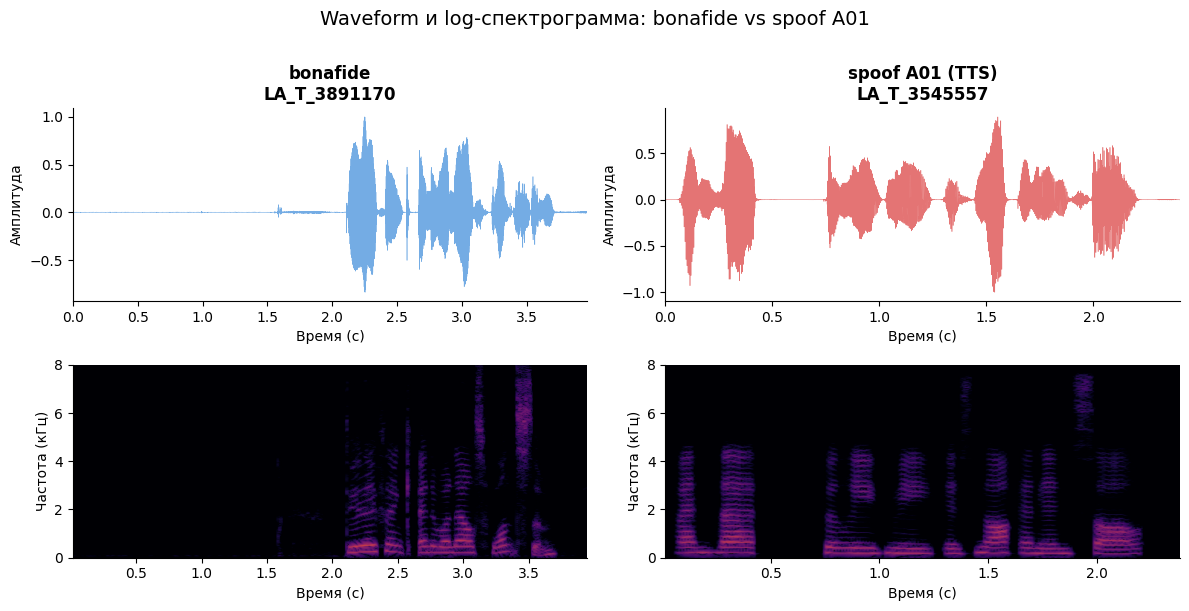

In [13]:
def plot_comparison(samples, title):
    n = len(samples)
    fig, axes = plt.subplots(2, n, figsize=(6 * n, 6))
    if n == 1:
        axes = axes.reshape(2, 1)

    for col, (wav, sr, label, color) in enumerate(samples):
        t = np.linspace(0, len(wav) / sr, len(wav))

        # waveform
        ax_w = axes[0][col]
        ax_w.plot(t, wav, color=color, linewidth=0.4, alpha=0.85)
        ax_w.set_title(label, fontsize=12, fontweight="bold")
        ax_w.set_ylabel("Амплитуда")
        ax_w.set_xlabel("Время (с)")
        ax_w.set_xlim(0, t[-1])
        ax_w.spines[["top", "right"]].set_visible(False)

        # log-spectrogram
        ax_s = axes[1][col]
        f, t_s, Sxx = scipy_spectrogram(wav, fs=sr, nperseg=512, noverlap=400)
        Sxx_log = 10 * np.log10(Sxx + 1e-10)
        ax_s.pcolormesh(t_s, f / 1000, Sxx_log, shading="gouraud",
                        cmap="inferno", vmin=-80, vmax=20)
        ax_s.set_ylabel("Частота (кГц)")
        ax_s.set_xlabel("Время (с)")
        ax_s.set_ylim(0, sr / 2000)
        ax_s.spines[["top", "right"]].set_visible(False)

    plt.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

plot_comparison(
    [
        (bon_wav,     bon_sr,  f"bonafide\n{bon_row.file_id}",     "#5c9ee0"),
        (spo_a01_wav, spo_sr,  f"spoof A01 (TTS)\n{spo_a01_row.file_id}", "#e05c5c"),
    ],
    "Waveform и log-спектрограмма: bonafide vs spoof A01"
)

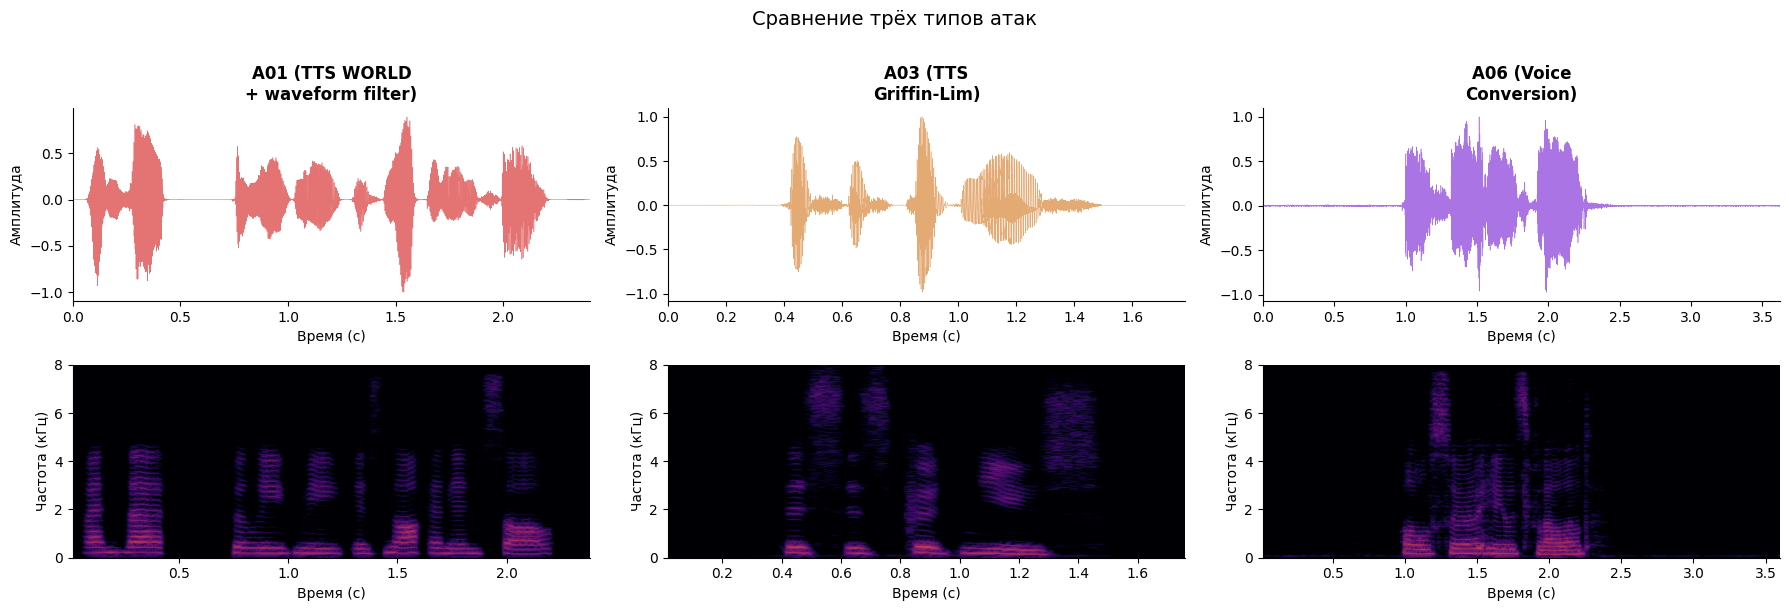

In [14]:
plot_comparison(
    [
        (spo_a01_wav, spo_sr, "A01 (TTS WORLD\n+ waveform filter)", "#e05c5c"),
        (spo_a03_wav, spo_sr, "A03 (TTS\nGriffin-Lim)",              "#e09b5c"),
        (spo_a06_wav, spo_sr, "A06 (Voice\nConversion)",              "#9b5ce0"),
    ],
    "Сравнение трёх типов атак"
)

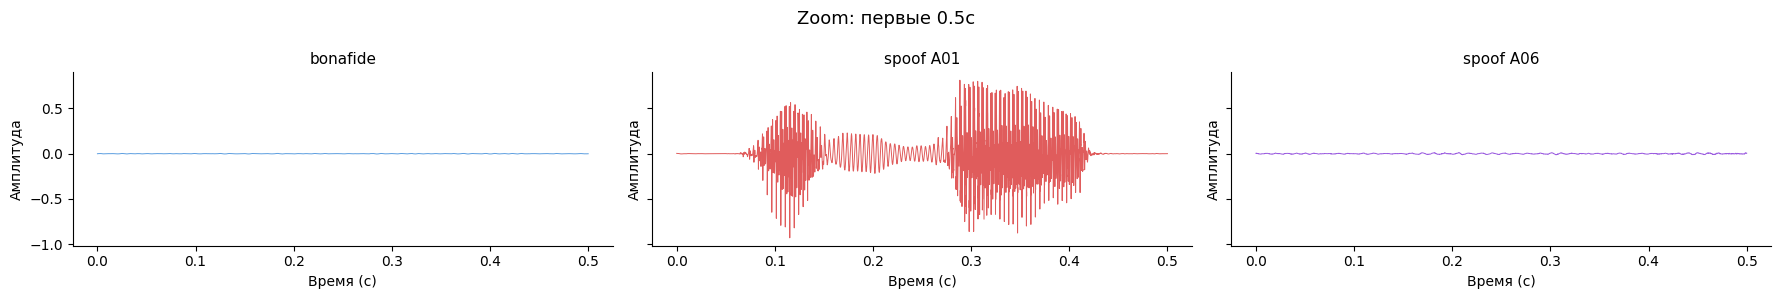

In [15]:
def zoom_waveform(samples, duration=0.5):
    fig, axes = plt.subplots(1, len(samples), figsize=(6 * len(samples), 3),
                             sharey=True)
    if len(samples) == 1:
        axes = [axes]

    for ax, (wav, sr, label, color) in zip(axes, samples):
        n = int(duration * sr)
        segment = wav[:n]
        t = np.linspace(0, duration, n)
        ax.plot(t, segment, color=color, linewidth=0.7)
        ax.set_title(label, fontsize=11)
        ax.set_xlabel("Время (с)")
        ax.set_ylabel("Амплитуда")
        ax.spines[["top", "right"]].set_visible(False)

    plt.suptitle(f"Zoom: первые {duration}с", fontsize=13)
    plt.tight_layout()
    plt.show()

zoom_waveform([
    (bon_wav,     bon_sr, "bonafide",  "#5c9ee0"),
    (spo_a01_wav, spo_sr, "spoof A01", "#e05c5c"),
    (spo_a06_wav, spo_sr, "spoof A06", "#9b5ce0"),
])

## ASVspoof 2021 LA

In [3]:
DATASET_2021_ROOT = "/kaggle/input/datasets/mohammedabdeldayem/avsspoof-2021"
LA2021_ROOT = f"{DATASET_2021_ROOT}/ASVspoof2021_LA_eval/ASVspoof2021_LA_eval"
LA2021_FLAC = f"{LA2021_ROOT}/flac"
LA2021_KEYS = f"{DATASET_2021_ROOT}/LA-keys-full/keys/LA/CM/trial_metadata.txt"

def parse_2021_keys(path, subset_filter="eval"):
    rows = []
    with open(path) as f:
        for line in f:
            p = line.split()
            if len(p) < 8:
                continue
            subset = p[7]
            if subset_filter and subset != subset_filter:
                continue
            rows.append({"speaker": p[0], "file_id": p[1], "attack": p[4], "label": p[5]})
    return pd.DataFrame(rows)

eval2021_df = parse_2021_keys(LA2021_KEYS, subset_filter="eval")
print(f"eval2021: {len(eval2021_df):,}")

eval2021: 148,176


bonafide =  14816  spoof = 133360  spoof/bonafide = 9.0


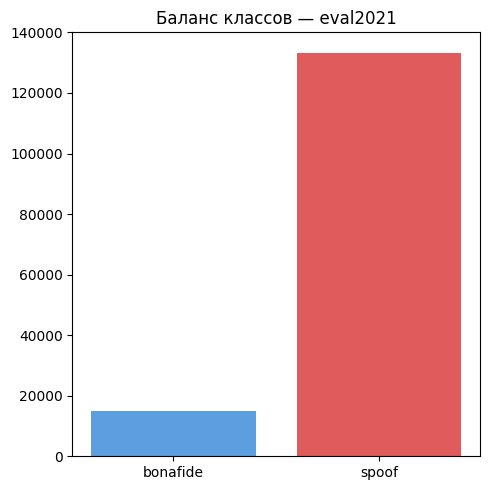

In [4]:
n_bon = (eval2021_df.label == "bonafide").sum()
n_spo = (eval2021_df.label == "spoof").sum()
print(f"bonafide = {n_bon:>6}  spoof = {n_spo:>6}  spoof/bonafide = {n_spo/n_bon:.1f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(["bonafide", "spoof"], [n_bon, n_spo], color=["#5c9ee0", "#e05c5c"])
ax.set_title("Баланс классов — eval2021")
plt.tight_layout()
plt.show()

attack
A07         10238
A08         10368
A09         10152
A10         10318
A11         10276
A12         10259
A13         10302
A14         10234
A15         10235
A16         10390
A17         10239
A18         10148
A19         10201
bonafide    14816
Name: count, dtype: int64


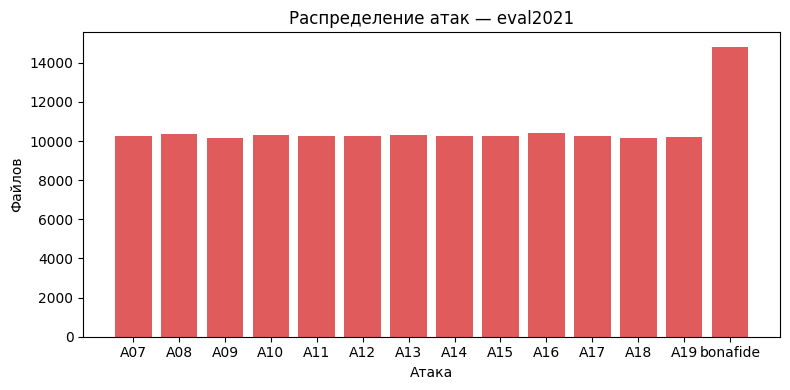

In [5]:
attack_counts = eval2021_df[eval2021_df.attack != "-"].attack.value_counts().sort_index()
print(attack_counts)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(attack_counts.index, attack_counts.values, color="#e05c5c")
ax.set_xlabel("Атака")
ax.set_ylabel("Файлов")
ax.set_title("Распределение атак — eval2021")
plt.tight_layout()
plt.show()

In [14]:
import soundfile as sf
from tqdm.notebook import tqdm

durations = []
for _, row in tqdm(eval2021_df.iterrows(), total=len(eval2021_df)):
    info = sf.info(f"{LA2021_FLAC}/{row.file_id}.flac")
    durations.append(info.duration)
eval2021_df["duration"] = durations

print(f"{'':10} {'min':>6} {'median':>8} {'max':>6} {'mean':>7}")
for label in ["bonafide", "spoof"]:
    d = eval2021_df[eval2021_df.label == label]["duration"]
    print(f"{label:10} {d.min():>6.2f} {d.median():>8.2f} {d.max():>6.2f} {d.mean():>7.2f}")

  0%|          | 0/148176 [00:00<?, ?it/s]

              min   median    max    mean
bonafide     1.06     3.22  13.40    3.39
spoof        0.52     2.34  13.02    2.64


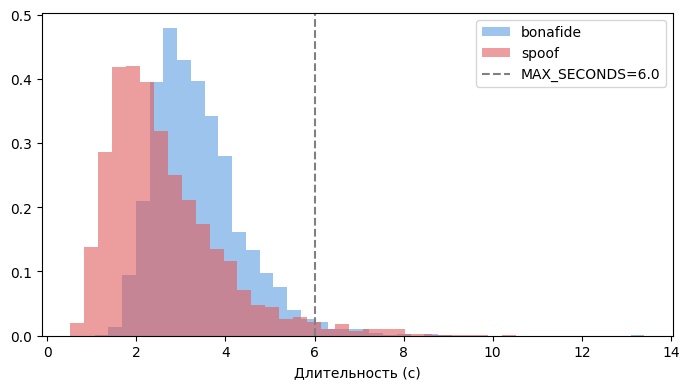

In [15]:
MAX_SECONDS = 6.0

fig, ax = plt.subplots(figsize=(7, 4))
for label in ["bonafide", "spoof"]:
    d = eval2021_df[eval2021_df.label == label]["duration"]
    ax.hist(d, bins=40, alpha=0.6, color="#5c9ee0" if label == "bonafide" else "#e05c5c", label=label, density=True)
ax.axvline(MAX_SECONDS, linestyle="--", color="gray", label=f"MAX_SECONDS={MAX_SECONDS}")
ax.set_xlabel("Длительность (с)")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
pct_over = (eval2021_df.duration > MAX_SECONDS).mean() * 100
print(f"Файлов длиннее {MAX_SECONDS}с: {pct_over:.2f}%")

for label in ["bonafide", "spoof"]:
    d = eval2021_df[eval2021_df.label == label]["duration"]
    pct = (d > MAX_SECONDS).mean() * 100
    print(f"{label:10} {pct:.2f}%")

Файлов длиннее 6.0с: 2.55%
bonafide   1.98%
spoof      2.62%
